In [25]:
# CELL 1

from pathlib import Path

import pandas as pd
from IPython.display import display

from api.process_ai.process.pipeline.process_configs import get_process_config
from api.process_ai.process.core.registry_loader import load_registry, get_step_codes
from api.process_ai.process.core.validate import validate_events_df
from api.process_ai.process.core.features import build_case_feature_matrix, compute_baselines

In [26]:
# CELL 2

from pathlib import Path

PROCESS_KEY = "warehouse"

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "api").exists() and (p / "model").exists():
            return p
    raise FileNotFoundError("Could not find project root")

def to_abs_path(path_like: str | Path, project_root: Path) -> Path:
    p = Path(path_like)
    return p if p.is_absolute() else (project_root / p).resolve()

PROJECT_ROOT = find_project_root()

cfg = get_process_config(PROCESS_KEY)
PROCESS_CODE = cfg.process_code

DATA_DIR = to_abs_path(cfg.data_dir, PROJECT_ROOT)
REGISTRY_DIR = to_abs_path(cfg.registry_dir, PROJECT_ROOT)
MODEL_DIR = to_abs_path(cfg.model_dir, PROJECT_ROOT)
REPORT_DIR = to_abs_path(cfg.report_dir, PROJECT_ROOT)

EVENTS_PATH = DATA_DIR / "events.csv"
CONTEXT_PATH = DATA_DIR / "cases_context.csv"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("PROCESS_KEY  :", PROCESS_KEY)
print("PROCESS_CODE :", PROCESS_CODE)
print("DATA_DIR     :", DATA_DIR)
print("REGISTRY_DIR :", REGISTRY_DIR)
print("MODEL_DIR    :", MODEL_DIR)
print("REPORT_DIR   :", REPORT_DIR)
print("EVENTS_PATH  :", EVENTS_PATH)
print("CONTEXT_PATH :", CONTEXT_PATH)

PROJECT_ROOT : D:\logistics_AI
PROCESS_KEY  : warehouse
PROCESS_CODE : WAREHOUSE_FULFILLMENT
DATA_DIR     : D:\logistics_AI\data\synth_optimal_3process_v1
REGISTRY_DIR : D:\logistics_AI\data\synth_optimal_3process_v1\registry
MODEL_DIR    : D:\logistics_AI\model\process_models
REPORT_DIR   : D:\logistics_AI\reports\warehouse
EVENTS_PATH  : D:\logistics_AI\data\synth_optimal_3process_v1\events.csv
CONTEXT_PATH : D:\logistics_AI\data\synth_optimal_3process_v1\cases_context.csv


In [27]:
# CELL 3

registry = load_registry(REGISTRY_DIR, PROCESS_CODE)
step_codes = get_step_codes(registry)

print("Number of step codes:", len(step_codes))
print("Step codes:")
print(step_codes)

Number of step codes: 23
Step codes:
['STEP_001_ORDER_CONFIRMED', 'STEP_002_FRAUD_CHECK', 'STEP_003_PAYMENT_VERIFIED', 'STEP_004_INVENTORY_RESERVED', 'STEP_005_WAVE_PLANNED', 'STEP_006_PICK_START', 'STEP_007_PICK_COMPLETE', 'STEP_008_REPLENISH_COMPLETE', 'STEP_009_SORTATION_COMPLETE', 'STEP_010_QC_COMPLETE', 'STEP_011_PACKING_START', 'STEP_012_LABEL_PRINT', 'STEP_013_WEIGH_DIM_CHECK', 'STEP_014_PACKING_COMPLETE', 'STEP_015_MANIFEST_CREATED', 'STEP_016_STAGING_COMPLETE', 'STEP_017_DOCK_ASSIGN', 'STEP_018_LOAD_TO_TRUCK', 'STEP_019_GATE_OUT_WAREHOUSE', 'STEP_020_HANDOFF_CARRIER', 'STEP_021_CARRIER_ACCEPTED', 'STEP_022_DEPART_WAREHOUSE', 'STEP_023_WAREHOUSE_CLOSEOUT']


In [28]:
# CELL 4

events_df = pd.read_csv(EVENTS_PATH)
cases_context_df = pd.read_csv(CONTEXT_PATH)

print("events_df columns:")
print(events_df.columns.tolist())

print("\ncases_context_df columns:")
print(cases_context_df.columns.tolist())

# Filter events theo process_code
if "process_code" in events_df.columns:
    events_df = events_df[events_df["process_code"].astype(str) == PROCESS_CODE].copy()

# Filter cases_context theo process_code nếu có,
# còn nếu không có thì lọc theo case_id xuất hiện trong events_df
if "process_code" in cases_context_df.columns:
    cases_context_df = cases_context_df[
        cases_context_df["process_code"].astype(str) == PROCESS_CODE
    ].copy()
elif "case_id" in cases_context_df.columns and "case_id" in events_df.columns:
    valid_case_ids = events_df["case_id"].astype(str).unique().tolist()
    cases_context_df = cases_context_df[
        cases_context_df["case_id"].astype(str).isin(valid_case_ids)
    ].copy()

print("\nevents_df shape:", events_df.shape)
print("cases_context_df shape:", cases_context_df.shape)

display(events_df.head())
display(cases_context_df.head())

events_df columns:
['process_code', 'case_id', 'step_code', 'start_time', 'end_time']

cases_context_df columns:
['case_id', 'distance_bucket', 'service_level', 'warehouse_code', 'hub_code', 'port_code', 'is_cross_border']

events_df shape: (276000, 5)
cases_context_df shape: (12000, 7)


,process_code,case_id,step_code,start_time,end_time
0,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_001_ORDER_CONFIRMED,2025-06-28T13:45:50,2025-06-28T13:54:31
1,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_002_FRAUD_CHECK,2025-06-28T13:54:31,2025-06-28T14:04:02
2,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_003_PAYMENT_VERIFIED,2025-06-28T14:04:02,2025-06-28T15:19:11
3,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_004_INVENTORY_RESERVED,2025-06-28T15:19:11,2025-06-28T15:28:34
4,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_005_WAVE_PLANNED,2025-06-28T15:28:34,2025-06-28T15:41:37


,case_id,distance_bucket,service_level,warehouse_code,hub_code,port_code,is_cross_border
0,ORD_5260181590,2,1,WH_HCM_01,HUB_HA_NOI,NaN,0
1,ORD_6723268656,2,1,WH_DN_01,HUB_HA_NOI,NaN,0
2,ORD_6668364507,2,1,WH_HCM_02,HUB_TAN_BINH,NaN,0
3,ORD_1923969372,2,1,WH_HCM_01,HUB_BINH_TAN,HAI_PHONG,1
4,ORD_1636246770,2,2,WH_HN_01,HUB_TAN_BINH,NaN,0


In [29]:
# CELL 5

validated_events_df, validation_report = validate_events_df(
    events_df,
    process_code=PROCESS_CODE,
    valid_steps=step_codes,
    allow_unknown_steps=False,
)

print("validation_report.ok:", validation_report.ok)
print("validation_report.errors:")
print(validation_report.errors)
print("validation_report.warnings:")
print(validation_report.warnings)

print("validated_events_df shape:", validated_events_df.shape)
display(validated_events_df.head())

validation_report.ok: True
validation_report.errors:
[]
validation_report.warnings:
[]
validated_events_df shape: (276000, 6)


,process_code,case_id,step_code,start_time,end_time,duration_sec
0,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_001_ORDER_CONFIRMED,2025-06-28 13:45:50,2025-06-28 13:54:31,521.0
1,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_002_FRAUD_CHECK,2025-06-28 13:54:31,2025-06-28 14:04:02,571.0
2,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_003_PAYMENT_VERIFIED,2025-06-28 14:04:02,2025-06-28 15:19:11,4509.0
3,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_004_INVENTORY_RESERVED,2025-06-28 15:19:11,2025-06-28 15:28:34,563.0
4,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_005_WAVE_PLANNED,2025-06-28 15:28:34,2025-06-28 15:41:37,783.0


In [30]:
# CELL 6

feature_df, feature_schema, feature_report = build_case_feature_matrix(
    validated_events_df,
    step_codes=step_codes,
    cases_context_df=cases_context_df,
    include_context_numeric=False,
)

print("feature_df shape:", feature_df.shape)
print("feature_schema keys:", list(feature_schema.keys()))
print("feature_report:", feature_report)

display(feature_df.head())

feature_df shape: (12000, 32)
feature_schema keys: ['step_codes', 'step_feature_cols', 'all_feature_cols']
feature_report: FeatureBuildReport(cases=12000, dropped_cases=0, repeated_case_count=0, missing_step_cases=0)


,STEP_001_ORDER_CONFIRMED_duration_min,STEP_002_FRAUD_CHECK_duration_min,STEP_003_PAYMENT_VERIFIED_duration_min,STEP_004_INVENTORY_RESERVED_duration_min,STEP_005_WAVE_PLANNED_duration_min,STEP_006_PICK_START_duration_min,STEP_007_PICK_COMPLETE_duration_min,STEP_008_REPLENISH_COMPLETE_duration_min,STEP_009_SORTATION_COMPLETE_duration_min,STEP_010_QC_COMPLETE_duration_min,...,STEP_023_WAREHOUSE_CLOSEOUT_duration_min,total_process_time_min,max_step_duration_min,mean_step_duration_min,std_step_duration_min,step_count_present,missing_step_count,missing_step_flag,repeated_step_total,repeated_step_flag
case_id,,,,,,,,,,,,,,,,,,,,,
ORD_0000312750,5.550000,13.366667,281.883333,2.816667,2.683333,16.216667,9.633333,16.916667,22.766667,15.300000,...,10.116667,552.133333,281.883333,24.005797,56.603810,23,0,0,0,0
ORD_0000434015,6.133333,11.383333,230.416667,10.183333,14.100000,8.100000,3.583333,6.100000,23.450000,11.966667,...,2.283333,470.316667,230.416667,20.448551,46.254168,23,0,0,0,0
ORD_0003576909,34.400000,16.100000,335.366667,7.883333,7.233333,10.333333,5.900000,4.450000,34.483333,4.583333,...,5.916667,606.616667,335.366667,26.374638,67.972709,23,0,0,0,0
ORD_0003662246,3.033333,13.450000,101.166667,6.300000,7.616667,10.833333,13.983333,5.416667,6.583333,11.650000,...,5.583333,319.950000,101.166667,13.910870,19.805767,23,0,0,0,0
ORD_0004464291,32.083333,4.783333,262.383333,2.600000,8.250000,15.550000,7.283333,7.800000,22.533333,27.883333,...,3.200000,516.900000,262.383333,22.473913,52.878672,23,0,0,0,0


In [31]:
# CELL 7

print("Feature columns:")
print(feature_df.columns.tolist())

print("\nFeature schema:")
print(feature_schema)

print("\nFeature report:")
print(feature_report)

display(feature_df.describe(include="all").T.head(20))

Feature columns:
['STEP_001_ORDER_CONFIRMED_duration_min', 'STEP_002_FRAUD_CHECK_duration_min', 'STEP_003_PAYMENT_VERIFIED_duration_min', 'STEP_004_INVENTORY_RESERVED_duration_min', 'STEP_005_WAVE_PLANNED_duration_min', 'STEP_006_PICK_START_duration_min', 'STEP_007_PICK_COMPLETE_duration_min', 'STEP_008_REPLENISH_COMPLETE_duration_min', 'STEP_009_SORTATION_COMPLETE_duration_min', 'STEP_010_QC_COMPLETE_duration_min', 'STEP_011_PACKING_START_duration_min', 'STEP_012_LABEL_PRINT_duration_min', 'STEP_013_WEIGH_DIM_CHECK_duration_min', 'STEP_014_PACKING_COMPLETE_duration_min', 'STEP_015_MANIFEST_CREATED_duration_min', 'STEP_016_STAGING_COMPLETE_duration_min', 'STEP_017_DOCK_ASSIGN_duration_min', 'STEP_018_LOAD_TO_TRUCK_duration_min', 'STEP_019_GATE_OUT_WAREHOUSE_duration_min', 'STEP_020_HANDOFF_CARRIER_duration_min', 'STEP_021_CARRIER_ACCEPTED_duration_min', 'STEP_022_DEPART_WAREHOUSE_duration_min', 'STEP_023_WAREHOUSE_CLOSEOUT_duration_min', 'total_process_time_min', 'max_step_duration_min

,count,mean,std,min,25%,50%,75%,max
STEP_001_ORDER_CONFIRMED_duration_min,12000.0,9.336781,5.533647,1.000000,5.533333,8.033333,11.683333,74.016667
STEP_002_FRAUD_CHECK_duration_min,12000.0,13.880358,8.114055,1.450000,8.316667,12.000000,17.316667,130.816667
STEP_003_PAYMENT_VERIFIED_duration_min,12000.0,210.881881,128.532967,27.983333,124.945833,179.750000,263.450000,2590.550000
STEP_004_INVENTORY_RESERVED_duration_min,12000.0,9.421607,5.652009,1.000000,5.566667,8.066667,11.766667,59.983333
STEP_005_WAVE_PLANNED_duration_min,12000.0,9.289767,5.505893,1.016667,5.583333,7.966667,11.566667,85.966667
STEP_006_PICK_START_duration_min,12000.0,11.497194,7.042451,1.050000,6.850000,9.883333,14.250000,160.933333
STEP_007_PICK_COMPLETE_duration_min,12000.0,11.753708,6.967692,1.283333,6.950000,10.100000,14.650000,97.583333
STEP_008_REPLENISH_COMPLETE_duration_min,12000.0,9.219515,5.513373,1.000000,5.483333,7.916667,11.550000,107.316667
STEP_009_SORTATION_COMPLETE_duration_min,12000.0,14.180839,9.537395,1.666667,8.250000,11.983333,17.550000,176.000000
STEP_010_QC_COMPLETE_duration_min,12000.0,14.180504,8.638988,1.233333,8.400000,12.100000,17.700000,120.666667


In [32]:
# CELL 8

baselines = compute_baselines(
    feature_df,
    step_codes=step_codes,
)

print("Baseline keys:")
print(baselines.keys())

print("\nStep baseline sample:")
display(pd.DataFrame(baselines.get("steps", {})).T.head())

Baseline keys:
dict_keys(['steps', 'total_process_time_min', 'n_cases_for_baseline'])

Step baseline sample:


,mean,std,p95,p99,missing_rate
STEP_001_ORDER_CONFIRMED,9.336781,5.533417,19.684167,28.500167,0.0
STEP_002_FRAUD_CHECK,13.880358,8.113717,29.033333,42.234000,0.0
STEP_003_PAYMENT_VERIFIED,210.881881,128.527612,446.948333,671.545000,0.0
STEP_004_INVENTORY_RESERVED,9.421607,5.651774,19.984167,29.483667,0.0
STEP_005_WAVE_PLANNED,9.289767,5.505663,19.617500,28.450167,0.0


In [33]:
# CELL 9

case_counts = (
    validated_events_df.groupby("case_id")
    .size()
    .reset_index(name="event_count")
    .sort_values("event_count", ascending=False)
)

print("Number of unique cases:", case_counts["case_id"].nunique())
display(case_counts.head(10))

Number of unique cases: 12000


,case_id,event_count
0,ORD_0000312750,23
1,ORD_0000434015,23
2,ORD_0003576909,23
3,ORD_0003662246,23
4,ORD_0004464291,23
5,ORD_0005053777,23
6,ORD_0005511584,23
7,ORD_0006530047,23
8,ORD_0010627475,23
9,ORD_0010926443,23


In [34]:
# CELL 10

step_counts = (
    validated_events_df["step_code"]
    .value_counts(dropna=False)
    .reset_index()
)
step_counts.columns = ["step_code", "count"]

display(step_counts)

,step_code,count
0,STEP_001_ORDER_CONFIRMED,12000
1,STEP_002_FRAUD_CHECK,12000
2,STEP_003_PAYMENT_VERIFIED,12000
3,STEP_004_INVENTORY_RESERVED,12000
4,STEP_005_WAVE_PLANNED,12000
5,STEP_006_PICK_START,12000
6,STEP_007_PICK_COMPLETE,12000
7,STEP_008_REPLENISH_COMPLETE,12000
8,STEP_009_SORTATION_COMPLETE,12000
9,STEP_010_QC_COMPLETE,12000


In [35]:
# CELL 11

missing_step_cases = []

total_cases = feature_df.index.astype(str).nunique()

for s in step_codes:
    case_has_step = (
        validated_events_df.loc[validated_events_df["step_code"] == s, "case_id"]
        .astype(str)
        .unique()
    )

    missing_count = total_cases - len(case_has_step)

    missing_step_cases.append({
        "step_code": s,
        "missing_case_count": missing_count,
    })

missing_step_df = pd.DataFrame(missing_step_cases).sort_values(
    "missing_case_count", ascending=False
)

display(missing_step_df)

,step_code,missing_case_count
0,STEP_001_ORDER_CONFIRMED,0
1,STEP_002_FRAUD_CHECK,0
2,STEP_003_PAYMENT_VERIFIED,0
3,STEP_004_INVENTORY_RESERVED,0
4,STEP_005_WAVE_PLANNED,0
5,STEP_006_PICK_START,0
6,STEP_007_PICK_COMPLETE,0
7,STEP_008_REPLENISH_COMPLETE,0
8,STEP_009_SORTATION_COMPLETE,0
9,STEP_010_QC_COMPLETE,0


In [36]:
# CELL 12

print("Final check:")
print("- Registry loaded:", registry is not None)
print("- Step codes loaded:", len(step_codes) > 0)
print("- Events validated:", validation_report.ok)
print("- Feature matrix ready:", not feature_df.empty)
print("- Baselines computed:", bool(baselines))

Final check:
- Registry loaded: True
- Step codes loaded: True
- Events validated: True
- Feature matrix ready: True
- Baselines computed: True


In [37]:
# CELL 13

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

REPORT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY = "#1f4e79"
SECONDARY = "#5b9bd5"
ACCENT = "#9dc3e6"
GRID = "#d9d9d9"
TEXT = "#222222"

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.labelcolor"] = TEXT
plt.rcParams["xtick.color"] = TEXT
plt.rcParams["ytick.color"] = TEXT
plt.rcParams["text.color"] = TEXT
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

def pretty_step_label(x: str) -> str:
    x = str(x)
    x = x.replace("STEP_", "")
    parts = x.split("_", 1)
    if len(parts) == 2 and parts[0].isdigit():
        x = parts[1]
    x = x.replace("_", " ").title()
    return x[:32] + "..." if len(x) > 32 else x

def style_axes(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.grid(axis=grid_axis, color=GRID, linestyle="-", linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)

def save_and_show(fig, path: Path):
    fig.tight_layout()
    fig.savefig(path, dpi=240, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved:", path)

In [38]:
# CELL 14

summary_rows = []

summary_rows.append({
    "metric": "process_code",
    "value": PROCESS_CODE,
})

summary_rows.append({
    "metric": "num_step_codes",
    "value": len(step_codes),
})

summary_rows.append({
    "metric": "validated_event_rows",
    "value": int(len(validated_events_df)),
})

summary_rows.append({
    "metric": "num_cases",
    "value": int(feature_df.shape[0]),
})

summary_rows.append({
    "metric": "num_features",
    "value": int(feature_df.shape[1]),
})

summary_rows.append({
    "metric": "dropped_cases",
    "value": int(getattr(feature_report, "dropped_cases", 0)),
})

summary_rows.append({
    "metric": "repeated_case_count",
    "value": int(getattr(feature_report, "repeated_case_count", 0)),
})

summary_rows.append({
    "metric": "missing_step_cases",
    "value": int(getattr(feature_report, "missing_step_cases", 0)),
})

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

,metric,value
0,process_code,WAREHOUSE_FULFILLMENT
1,num_step_codes,23
2,validated_event_rows,276000
3,num_cases,12000
4,num_features,32
5,dropped_cases,0
6,repeated_case_count,0
7,missing_step_cases,0


In [39]:
# CELL 15

warehouse_pattern = r"PICK|PACK|STAGE|STAGING|QC|QUALITY|REWORK|PUTAWAY|SORT|ALLOC|DOCK|LOAD"

step_duration_summary_df = (
    validated_events_df.assign(
        start_time=pd.to_datetime(validated_events_df["start_time"]),
        end_time=pd.to_datetime(validated_events_df["end_time"]),
    )
    .assign(duration_min=lambda d: (d["end_time"] - d["start_time"]).dt.total_seconds() / 60.0)
    .groupby("step_code")["duration_min"]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
)

step_duration_summary_df["step_label"] = step_duration_summary_df["step_code"].map(pretty_step_label)

warehouse_step_duration_df = step_duration_summary_df[
    step_duration_summary_df["step_code"].astype(str).str.contains(warehouse_pattern, case=False, regex=True)
].copy()

if warehouse_step_duration_df.empty:
    warehouse_step_duration_df = step_duration_summary_df.copy()

warehouse_step_duration_df = warehouse_step_duration_df.sort_values("mean", ascending=False)

display(warehouse_step_duration_df)

,step_code,count,mean,median,max,step_label
17,STEP_018_LOAD_TO_TRUCK,12000,23.482339,20.150000,603.383333,Load To Truck
10,STEP_011_PACKING_START,12000,16.569981,14.250000,157.800000,Packing Start
13,STEP_014_PACKING_COMPLETE,12000,16.568665,14.066667,173.900000,Packing Complete
8,STEP_009_SORTATION_COMPLETE,12000,14.180839,11.983333,176.000000,Sortation Complete
9,STEP_010_QC_COMPLETE,12000,14.180504,12.100000,120.666667,Qc Complete
6,STEP_007_PICK_COMPLETE,12000,11.753708,10.100000,97.583333,Pick Complete
5,STEP_006_PICK_START,12000,11.497194,9.883333,160.933333,Pick Start
16,STEP_017_DOCK_ASSIGN,12000,9.337660,8.000000,76.150000,Dock Assign
15,STEP_016_STAGING_COMPLETE,12000,9.332124,8.100000,86.466667,Staging Complete


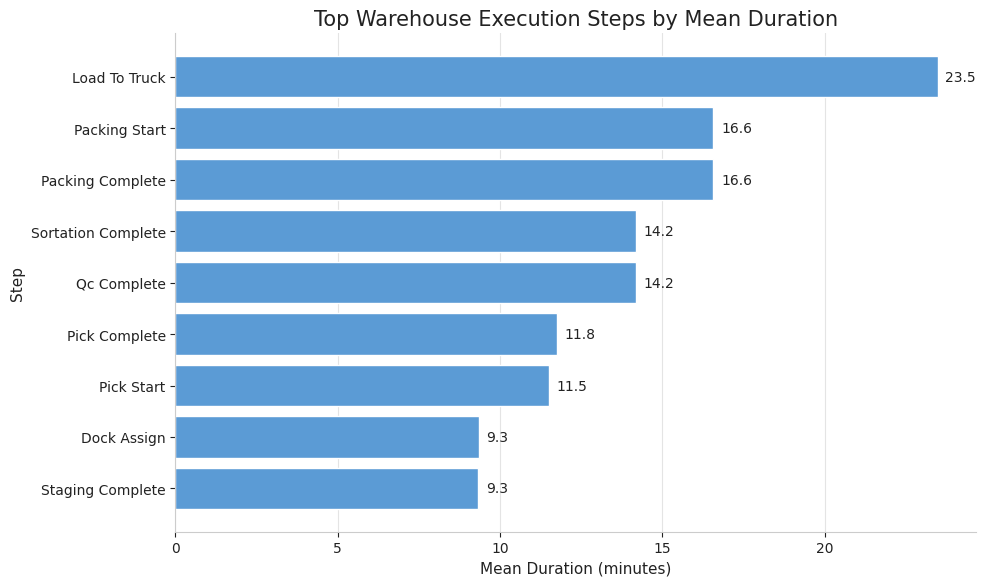

Saved: D:\logistics_AI\reports\warehouse\warehouse_top_warehouse_mean_duration.png


In [40]:
# CELL 16

top_mean_df = warehouse_step_duration_df.head(10).copy().sort_values("mean", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_mean_df["step_label"], top_mean_df["mean"], color=SECONDARY, edgecolor="white")
ax.set_title("Top Warehouse Execution Steps by Mean Duration")
ax.set_xlabel("Mean Duration (minutes)")
ax.set_ylabel("Step")
style_axes(ax, grid_axis="x")

for bar in bars:
    w = bar.get_width()
    ax.text(w + max(top_mean_df["mean"]) * 0.01, bar.get_y() + bar.get_height()/2, f"{w:.1f}",
            va="center", ha="left", fontsize=10)

mean_duration_path = REPORT_DIR / f"{PROCESS_KEY}_top_warehouse_mean_duration.png"
save_and_show(fig, mean_duration_path)

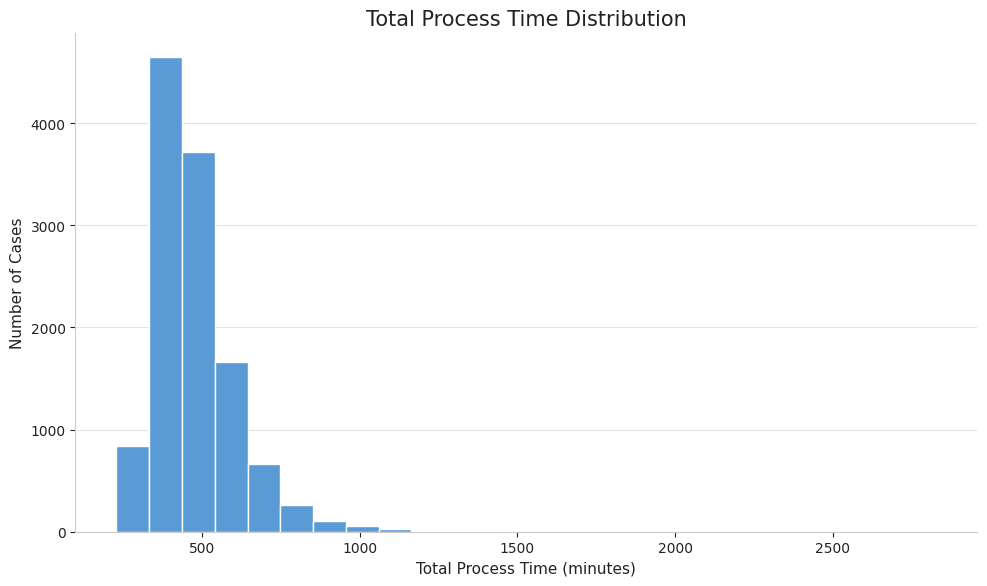

Saved: D:\logistics_AI\reports\warehouse\warehouse_total_process_time_hist.png


In [41]:
# CELL 17

if "total_process_time_min" in feature_df.columns:
    total_time_series = feature_df["total_process_time_min"].copy()
else:
    step_duration_cols = [c for c in feature_df.columns if str(c).endswith("_duration_min")]
    total_time_series = feature_df[step_duration_cols].sum(axis=1)

total_time_df = pd.DataFrame({
    "case_id": feature_df.index.astype(str),
    "total_process_time_min": total_time_series.values,
}).sort_values("total_process_time_min", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(total_time_df["total_process_time_min"], bins=25, color=SECONDARY, edgecolor="white")
ax.set_title("Total Process Time Distribution")
ax.set_xlabel("Total Process Time (minutes)")
ax.set_ylabel("Number of Cases")
style_axes(ax, grid_axis="y")

total_time_hist_path = REPORT_DIR / f"{PROCESS_KEY}_total_process_time_hist.png"
save_and_show(fig, total_time_hist_path)

In [42]:
# CELL 18

baseline_step_df = pd.DataFrame(baselines.get("steps", {})).T.reset_index()
baseline_step_df = baseline_step_df.rename(columns={"index": "step_code"})

for col in ["mean", "std", "p95", "count"]:
    if col in baseline_step_df.columns:
        baseline_step_df[col] = pd.to_numeric(baseline_step_df[col], errors="coerce")

baseline_step_df["step_label"] = baseline_step_df["step_code"].map(pretty_step_label)

warehouse_baseline_df = baseline_step_df[
    baseline_step_df["step_code"].astype(str).str.contains(warehouse_pattern, case=False, regex=True)
].copy()

if warehouse_baseline_df.empty:
    warehouse_baseline_df = baseline_step_df.copy()

warehouse_baseline_df = warehouse_baseline_df.sort_values("p95", ascending=False)

display(warehouse_baseline_df)

,step_code,mean,std,p95,p99,missing_rate,step_label
17,STEP_018_LOAD_TO_TRUCK,23.482339,15.044421,49.035833,73.517000,0.0,Load To Truck
13,STEP_014_PACKING_COMPLETE,16.568665,10.486586,35.550000,51.950500,0.0,Packing Complete
10,STEP_011_PACKING_START,16.569981,10.164092,35.200833,51.834167,0.0,Packing Start
8,STEP_009_SORTATION_COMPLETE,14.180839,9.536997,30.034167,46.719667,0.0,Sortation Complete
9,STEP_010_QC_COMPLETE,14.180504,8.638628,29.950000,44.017833,0.0,Qc Complete
6,STEP_007_PICK_COMPLETE,11.753708,6.967402,25.066667,36.117167,0.0,Pick Complete
5,STEP_006_PICK_START,11.497194,7.042158,24.100000,36.283333,0.0,Pick Start
16,STEP_017_DOCK_ASSIGN,9.337660,5.674608,19.800833,29.567333,0.0,Dock Assign
15,STEP_016_STAGING_COMPLETE,9.332124,5.526315,19.466667,28.166833,0.0,Staging Complete


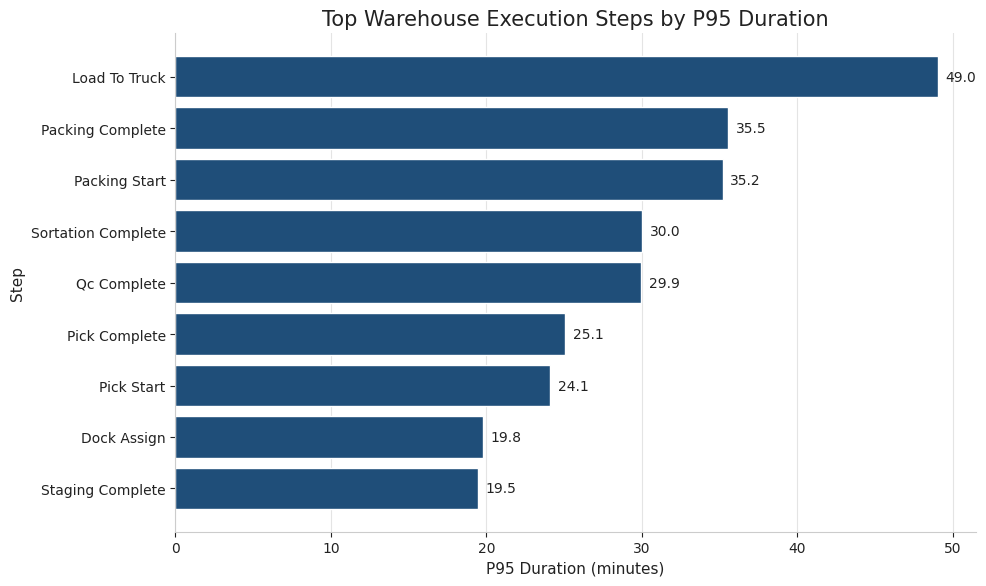

Saved: D:\logistics_AI\reports\warehouse\warehouse_top_warehouse_p95_duration.png


In [43]:
# CELL 19

top_p95_df = warehouse_baseline_df.head(10).copy().sort_values("p95", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_p95_df["step_label"], top_p95_df["p95"], color=PRIMARY, edgecolor="white")
ax.set_title("Top Warehouse Execution Steps by P95 Duration")
ax.set_xlabel("P95 Duration (minutes)")
ax.set_ylabel("Step")
style_axes(ax, grid_axis="x")

for bar in bars:
    w = bar.get_width()
    ax.text(w + max(top_p95_df["p95"]) * 0.01, bar.get_y() + bar.get_height()/2, f"{w:.1f}",
            va="center", ha="left", fontsize=10)

baseline_p95_path = REPORT_DIR / f"{PROCESS_KEY}_top_warehouse_p95_duration.png"
save_and_show(fig, baseline_p95_path)

In [44]:
# CELL 20

missing_step_cases = []
total_cases = feature_df.index.astype(str).nunique()

for s in step_codes:
    case_has_step = (
        validated_events_df.loc[validated_events_df["step_code"] == s, "case_id"]
        .astype(str)
        .nunique()
    )
    missing_step_cases.append({
        "step_code": s,
        "missing_case_count": total_cases - case_has_step,
    })

missing_step_df = pd.DataFrame(missing_step_cases).sort_values("missing_case_count", ascending=False)
missing_step_df["step_label"] = missing_step_df["step_code"].map(pretty_step_label)

display(missing_step_df)

if missing_step_df["missing_case_count"].max() > 0:
    top_missing_df = missing_step_df.head(10).copy().sort_values("missing_case_count", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top_missing_df["step_label"], top_missing_df["missing_case_count"], color=ACCENT, edgecolor="white")
    ax.set_title("Top Steps with Missing Cases")
    ax.set_xlabel("Number of Missing Cases")
    ax.set_ylabel("Step")
    style_axes(ax, grid_axis="x")

    for bar in bars:
        w = bar.get_width()
        ax.text(w + max(top_missing_df["missing_case_count"].max(), 1) * 0.01,
                bar.get_y() + bar.get_height()/2,
                f"{int(w)}", va="center", ha="left", fontsize=10)

    missing_step_path = REPORT_DIR / f"{PROCESS_KEY}_top_missing_step_cases.png"
    save_and_show(fig, missing_step_path)
else:
    print("No missing-step issue detected. Skipping missing-step chart.")

,step_code,missing_case_count,step_label
0,STEP_001_ORDER_CONFIRMED,0,Order Confirmed
1,STEP_002_FRAUD_CHECK,0,Fraud Check
2,STEP_003_PAYMENT_VERIFIED,0,Payment Verified
3,STEP_004_INVENTORY_RESERVED,0,Inventory Reserved
4,STEP_005_WAVE_PLANNED,0,Wave Planned
5,STEP_006_PICK_START,0,Pick Start
6,STEP_007_PICK_COMPLETE,0,Pick Complete
7,STEP_008_REPLENISH_COMPLETE,0,Replenish Complete
8,STEP_009_SORTATION_COMPLETE,0,Sortation Complete
9,STEP_010_QC_COMPLETE,0,Qc Complete


No missing-step issue detected. Skipping missing-step chart.


In [45]:
# CELL 21

display(
    warehouse_step_duration_df.sort_values("median", ascending=False).head(10)[
        ["step_code", "count", "mean", "median", "max"]
    ]
)

,step_code,count,mean,median,max
17,STEP_018_LOAD_TO_TRUCK,12000,23.482339,20.150000,603.383333
10,STEP_011_PACKING_START,12000,16.569981,14.250000,157.800000
13,STEP_014_PACKING_COMPLETE,12000,16.568665,14.066667,173.900000
9,STEP_010_QC_COMPLETE,12000,14.180504,12.100000,120.666667
8,STEP_009_SORTATION_COMPLETE,12000,14.180839,11.983333,176.000000
6,STEP_007_PICK_COMPLETE,12000,11.753708,10.100000,97.583333
5,STEP_006_PICK_START,12000,11.497194,9.883333,160.933333
15,STEP_016_STAGING_COMPLETE,12000,9.332124,8.100000,86.466667
16,STEP_017_DOCK_ASSIGN,12000,9.337660,8.000000,76.150000


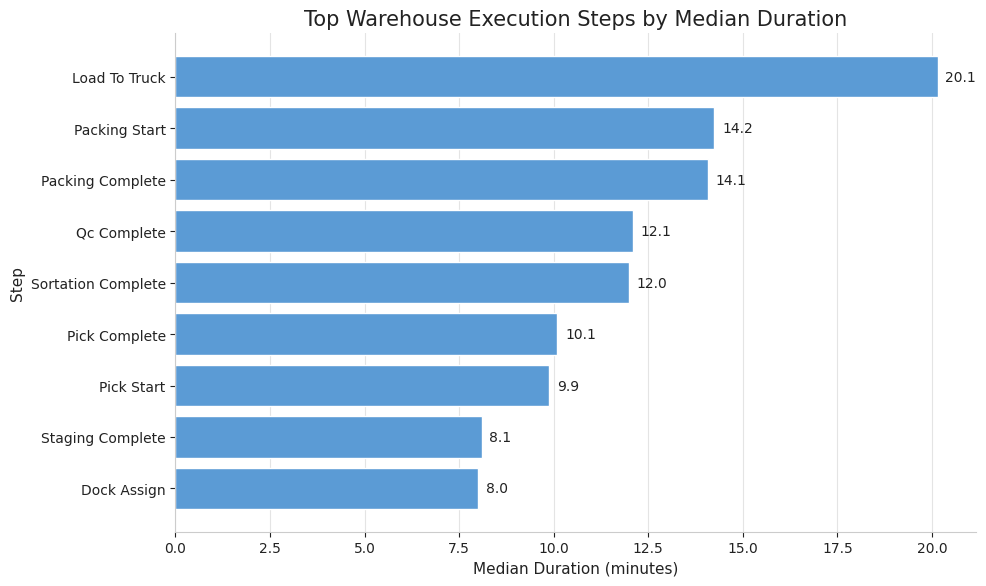

Saved: D:\logistics_AI\reports\warehouse\warehouse_top_warehouse_median_duration.png


In [46]:
# CELL 22

top_median_df = (
    warehouse_step_duration_df.sort_values("median", ascending=False)
    .head(10)
    .copy()
    .sort_values("median", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_median_df["step_label"], top_median_df["median"], color=SECONDARY, edgecolor="white")
ax.set_title("Top Warehouse Execution Steps by Median Duration")
ax.set_xlabel("Median Duration (minutes)")
ax.set_ylabel("Step")
style_axes(ax, grid_axis="x")

for bar in bars:
    w = bar.get_width()
    ax.text(w + max(top_median_df["median"]) * 0.01, bar.get_y() + bar.get_height()/2, f"{w:.1f}",
            va="center", ha="left", fontsize=10)

step_median_path = REPORT_DIR / f"{PROCESS_KEY}_top_warehouse_median_duration.png"
save_and_show(fig, step_median_path)

In [47]:
# CELL 23

summary_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_summary_metrics.csv", index=False)
total_time_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_total_process_time.csv", index=False)
baseline_step_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_baseline_steps.csv", index=False)
step_duration_summary_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_step_duration_summary.csv", index=False)
missing_step_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_missing_steps.csv", index=False)

print("Saved CSV files to:", REPORT_DIR)

Saved CSV files to: D:\logistics_AI\reports\warehouse


In [48]:
# CELL 24

generated_files = [
    REPORT_DIR / f"{PROCESS_KEY}_top_step_mean_duration.png",
    REPORT_DIR / f"{PROCESS_KEY}_total_process_time_hist.png",
    REPORT_DIR / f"{PROCESS_KEY}_top_step_p95.png",
    REPORT_DIR / f"{PROCESS_KEY}_top_step_median_duration.png",
    REPORT_DIR / f"{PROCESS_KEY}_summary_metrics.csv",
    REPORT_DIR / f"{PROCESS_KEY}_total_process_time.csv",
    REPORT_DIR / f"{PROCESS_KEY}_baseline_steps.csv",
    REPORT_DIR / f"{PROCESS_KEY}_step_duration_summary.csv",
    REPORT_DIR / f"{PROCESS_KEY}_missing_steps.csv",
]

optional_missing_chart = REPORT_DIR / f"{PROCESS_KEY}_top_missing_step_cases.png"
if optional_missing_chart.exists():
    generated_files.append(optional_missing_chart)

for f in generated_files:
    print(f.exists(), "-", f)

False - D:\logistics_AI\reports\warehouse\warehouse_top_step_mean_duration.png
True - D:\logistics_AI\reports\warehouse\warehouse_total_process_time_hist.png
False - D:\logistics_AI\reports\warehouse\warehouse_top_step_p95.png
False - D:\logistics_AI\reports\warehouse\warehouse_top_step_median_duration.png
True - D:\logistics_AI\reports\warehouse\warehouse_summary_metrics.csv
True - D:\logistics_AI\reports\warehouse\warehouse_total_process_time.csv
True - D:\logistics_AI\reports\warehouse\warehouse_baseline_steps.csv
True - D:\logistics_AI\reports\warehouse\warehouse_step_duration_summary.csv
True - D:\logistics_AI\reports\warehouse\warehouse_missing_steps.csv
